In [5]:
import gymnasium as gym
from gymnasium.envs.registration import register
import pulsrEnv   # must import the file that defines PulsrEnv

# Clear old registrations (useful in notebooks)
if "pulsr-virtualenv-v0" in gym.envs.registration.registry:
    del gym.envs.registration.registry["pulsr-virtualenv-v0"]

register(
    id="pulsr-virtualenv-v0",
    entry_point="pulsrEnv:PulsrEnv",  # module_name:class_name
)

env = gym.make("pulsr-virtualenv-v0")
print("Env created:", env)

Env created: <OrderEnforcing<PassiveEnvChecker<PulsrEnv<pulsr-virtualenv-v0>>>>


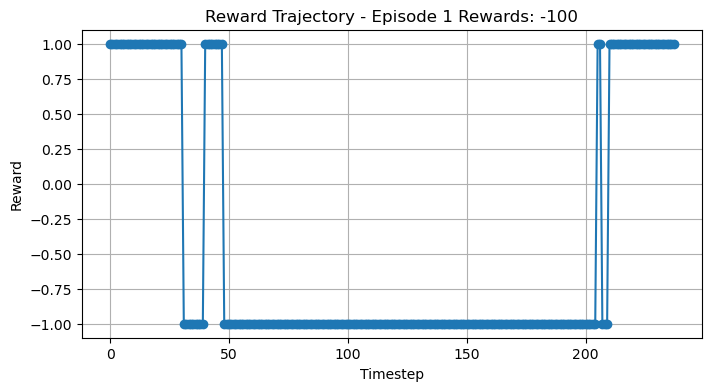

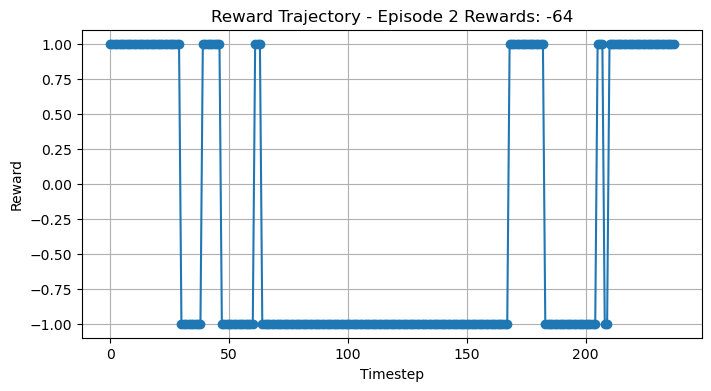

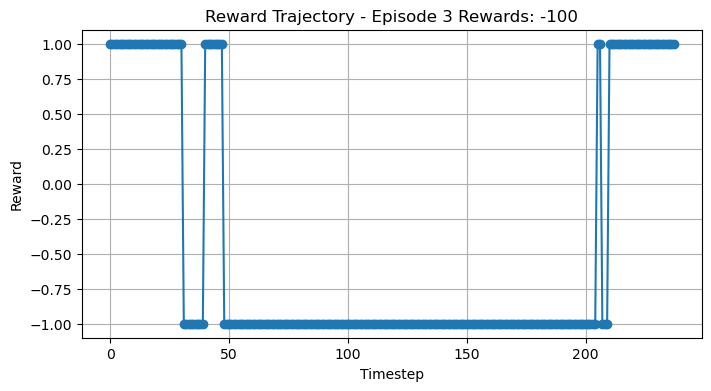

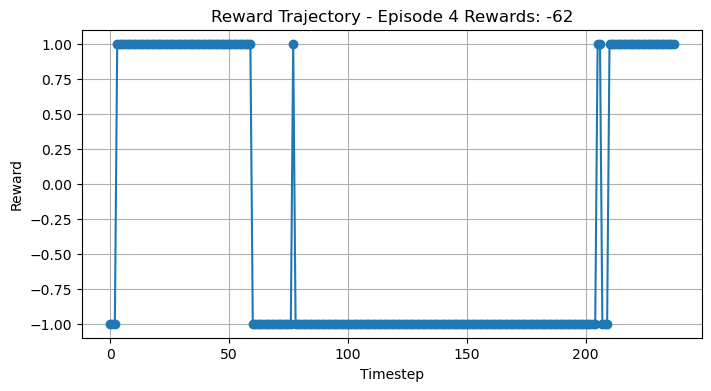

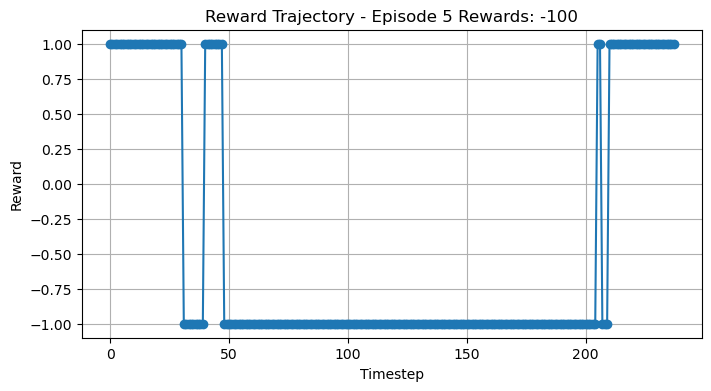

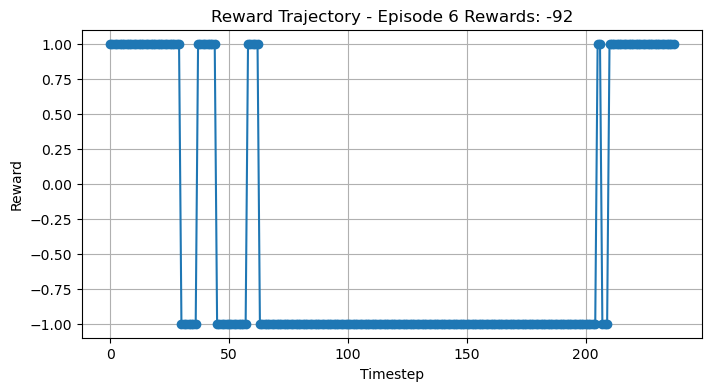

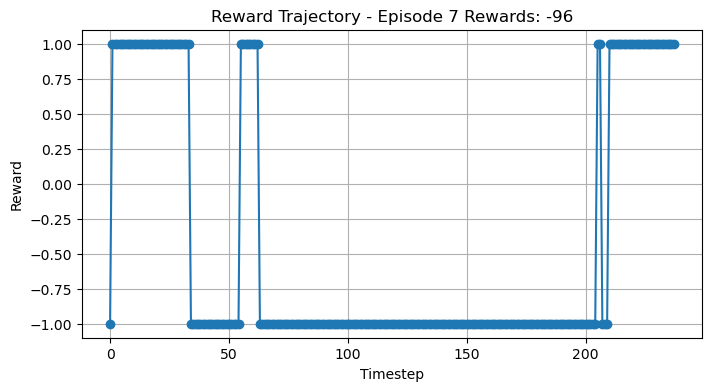

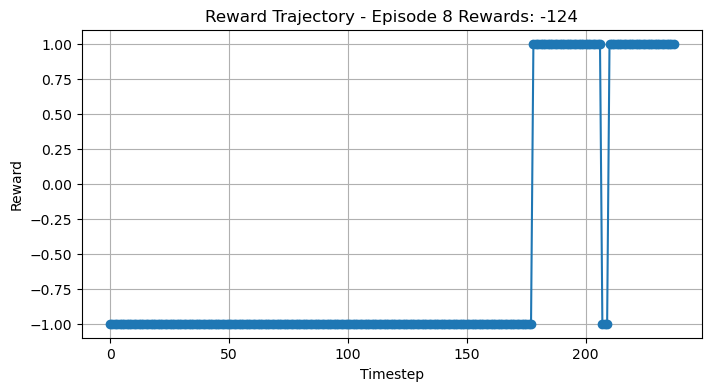

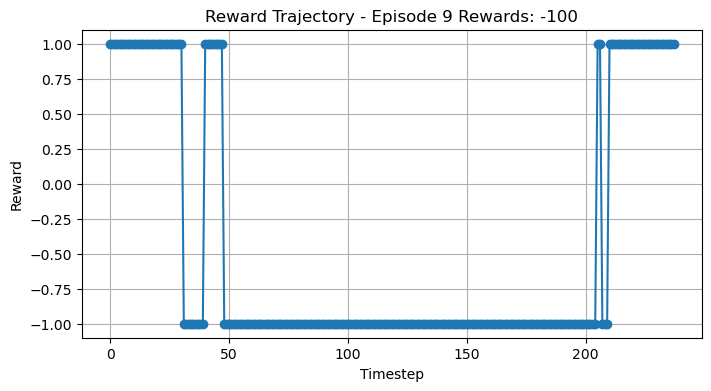

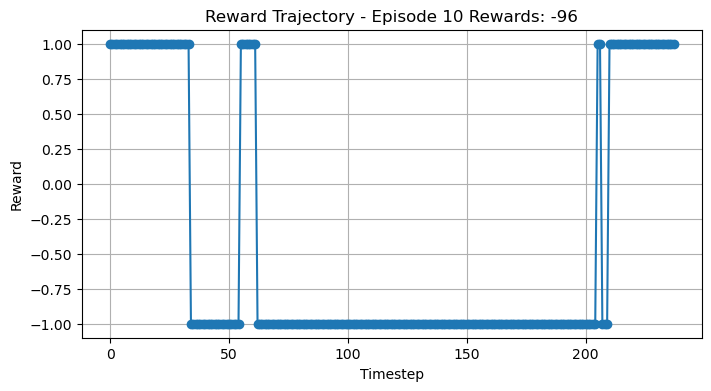

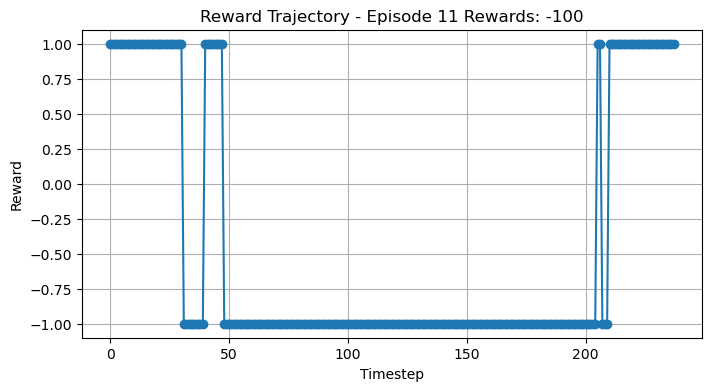

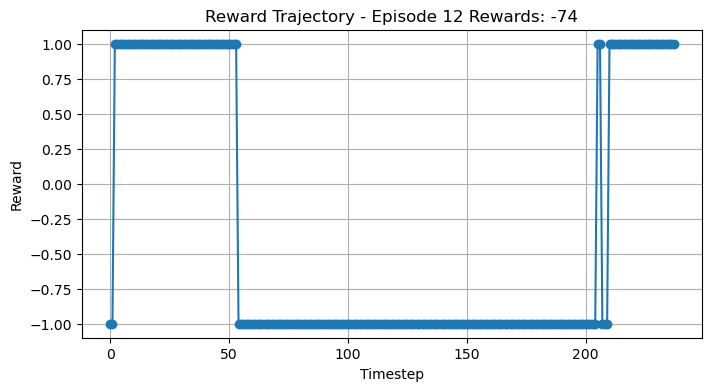

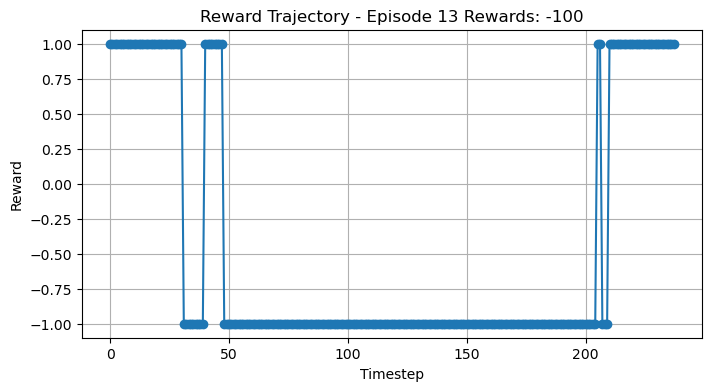

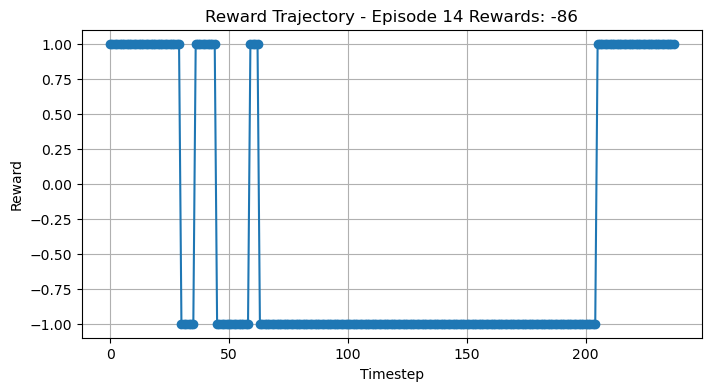

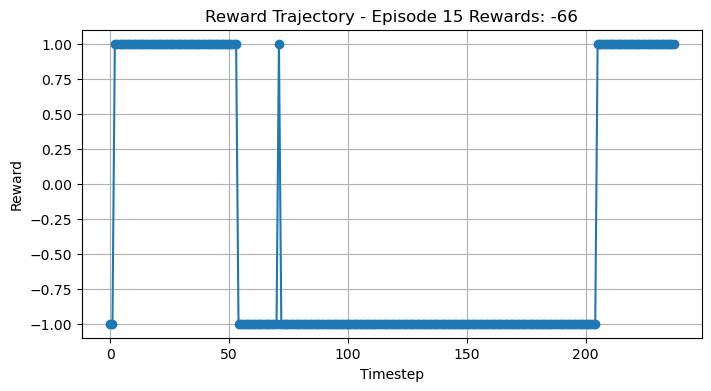

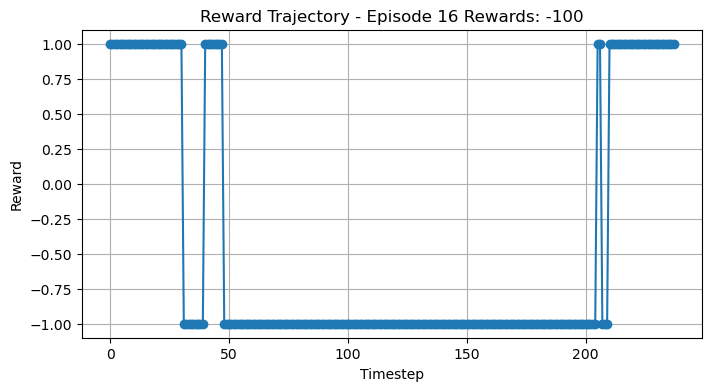

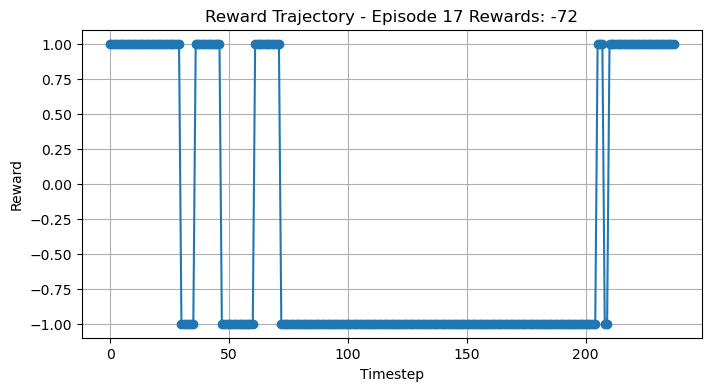

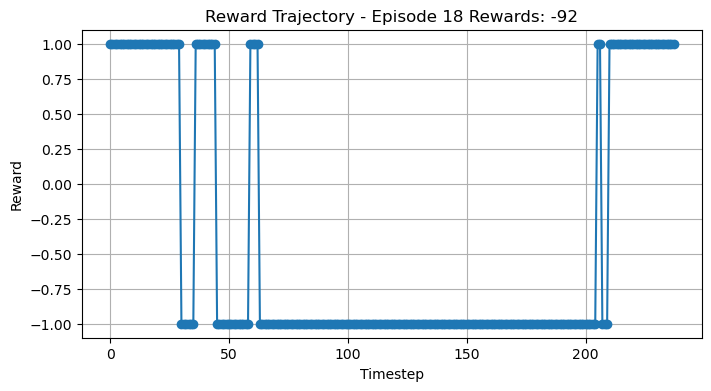

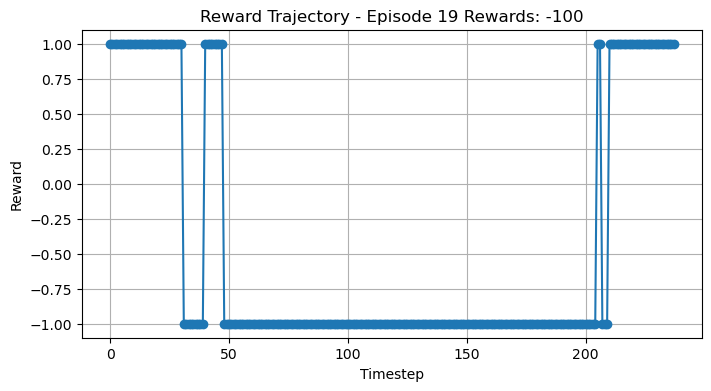

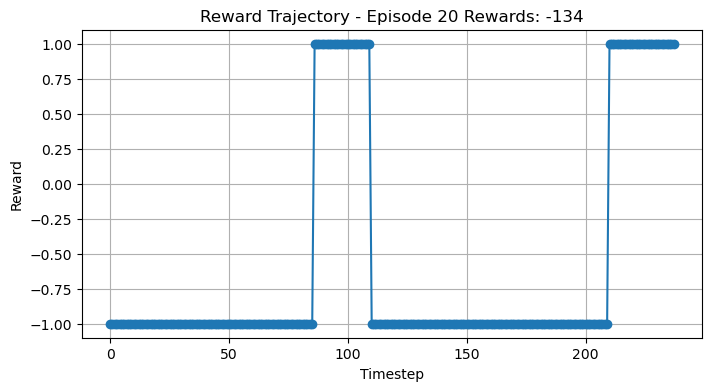

In [12]:
import gymnasium as gym
import pulsrEnv 
from stable_baselines3 import DQN
import matplotlib.pyplot as plt
import numpy as np


env = gym.make("pulsr-virtualenv-v0", workspace_csv="workspace_coordinates/workspace_1.csv", trajectory_csv="track_trajectory_coordinates/track_trajectory_1.csv")

# Load model
model = DQN.load("models/dqn_pulsr_virtualenv_10000")
n_episodes = 20
timesteps_per_episode = 239

obs, info = env.reset()
sum_ep_r = []

for ep in range(n_episodes):
    episode_rewards = []
    for t in range(timesteps_per_episode):
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        episode_rewards.append(reward)

        if terminated or truncated:
            break

    sum_ep_r.append(sum(episode_rewards))
    # --- Plot after each episode ---
    plt.figure(figsize=(8,4))
    plt.plot(range(len(episode_rewards)), episode_rewards, marker="o")
    plt.title(f"Reward Trajectory - Episode {ep+1} Rewards: {sum(episode_rewards)}")
    plt.xlabel("Timestep")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.show()

    # Reset env for next episode
    obs, info = env.reset()
   

In [14]:
# mean reward for 10000 timesteps_model
np.mean(sum_ep_r)

np.float64(-92.9)

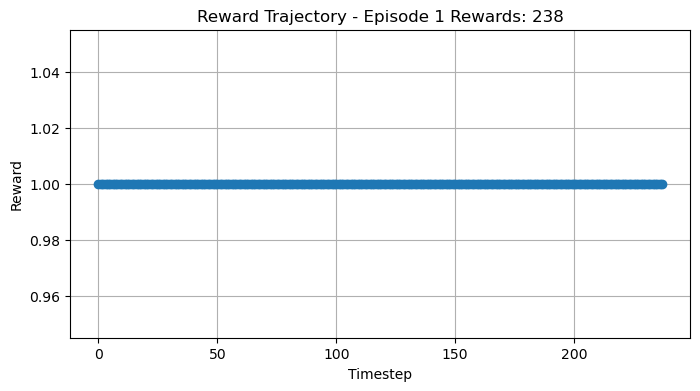

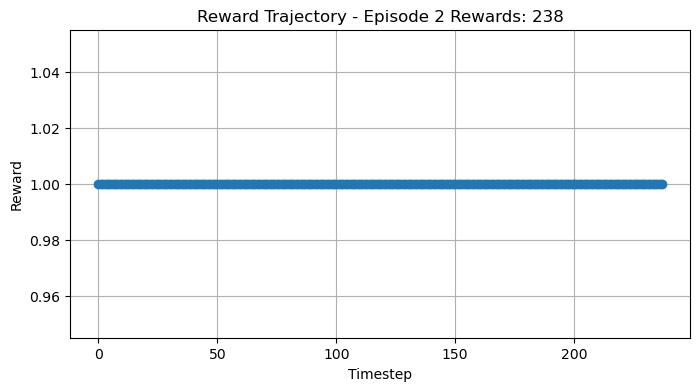

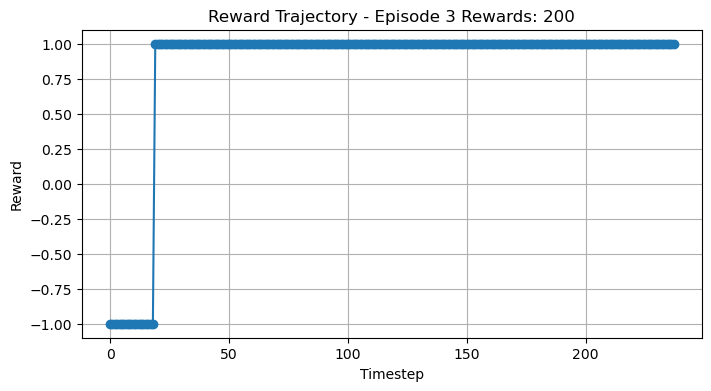

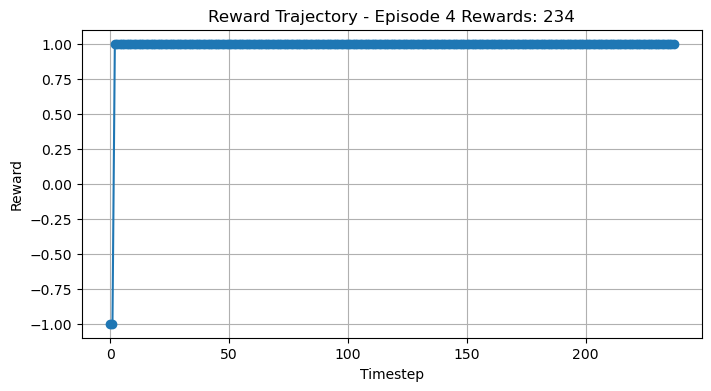

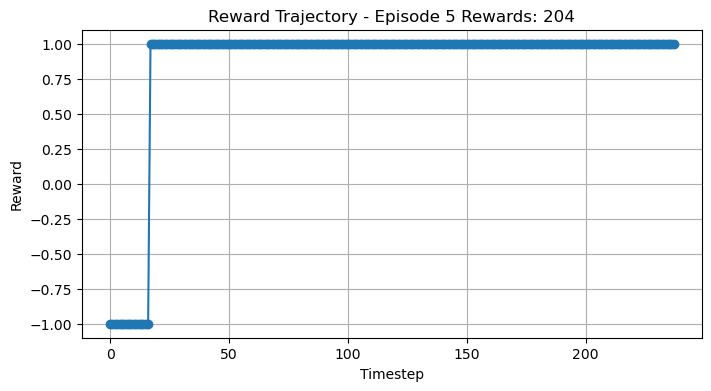

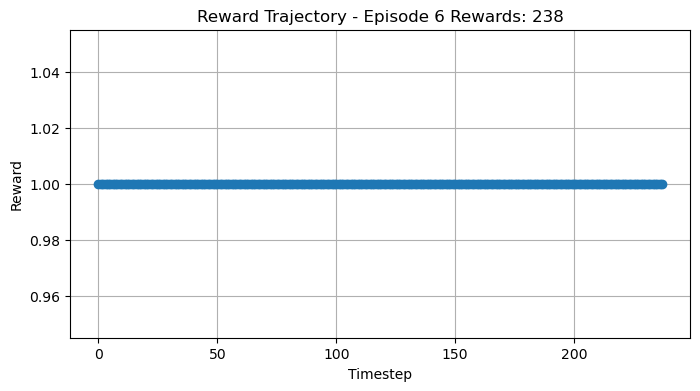

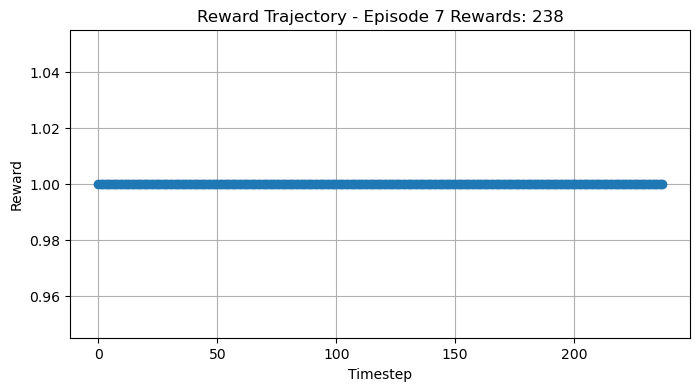

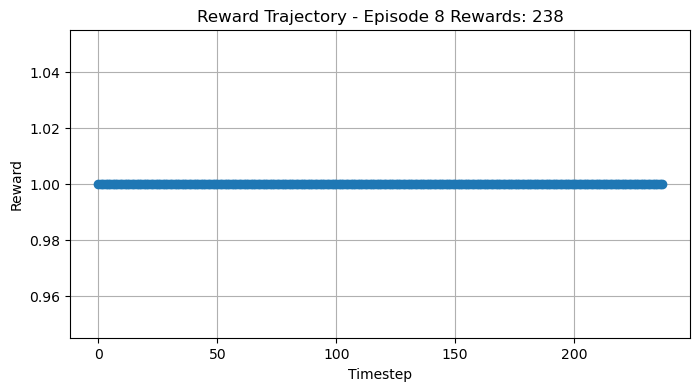

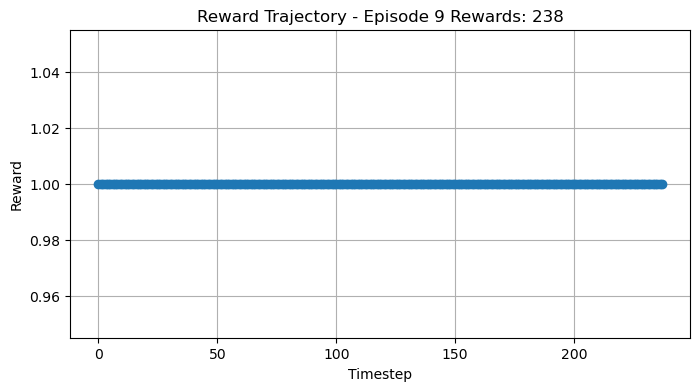

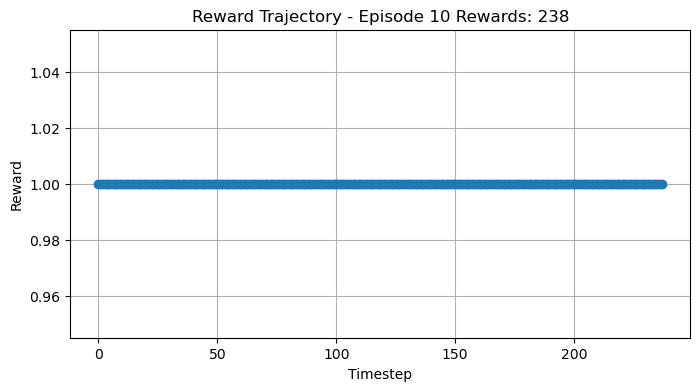

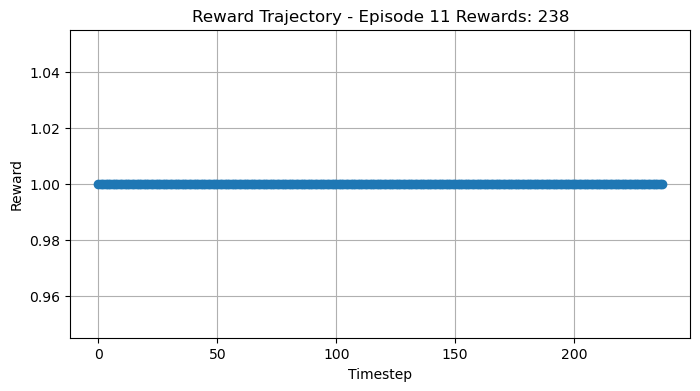

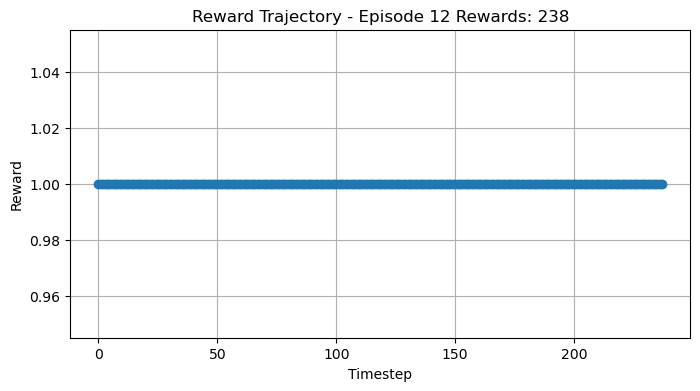

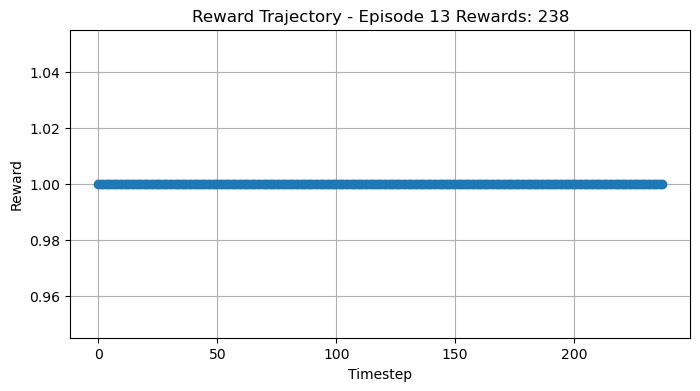

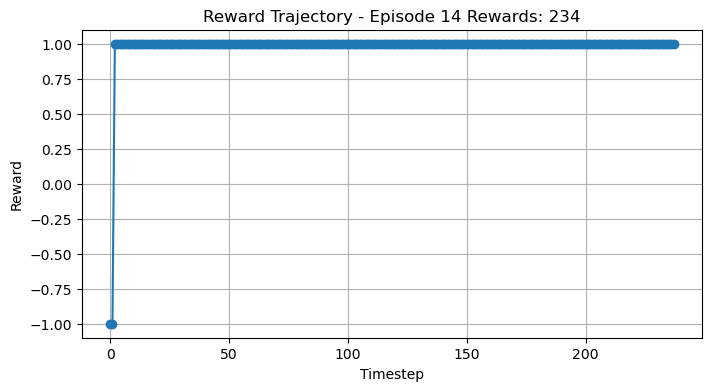

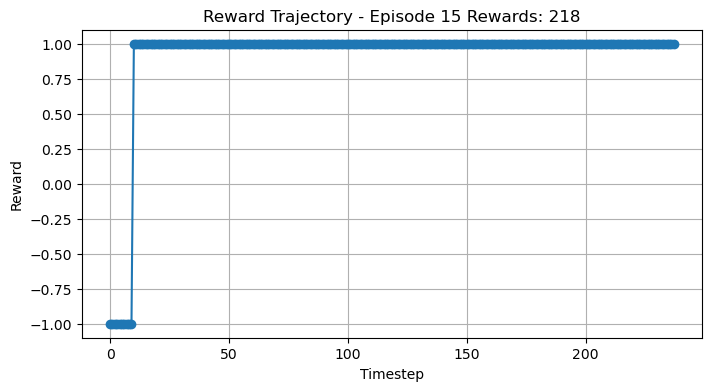

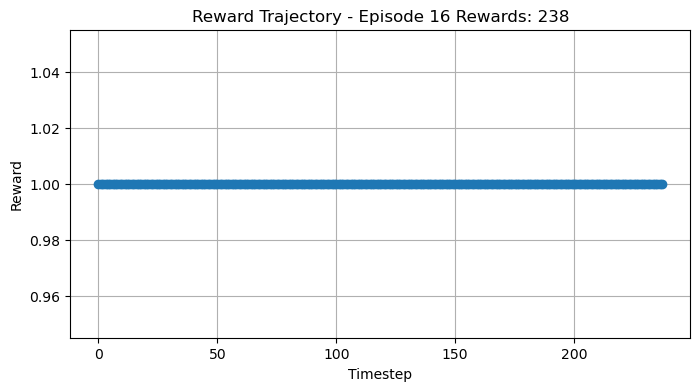

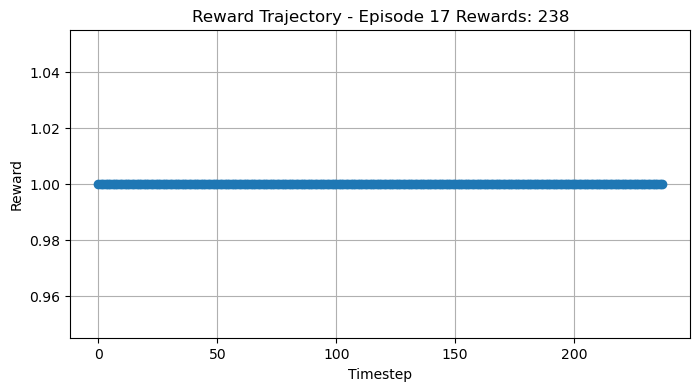

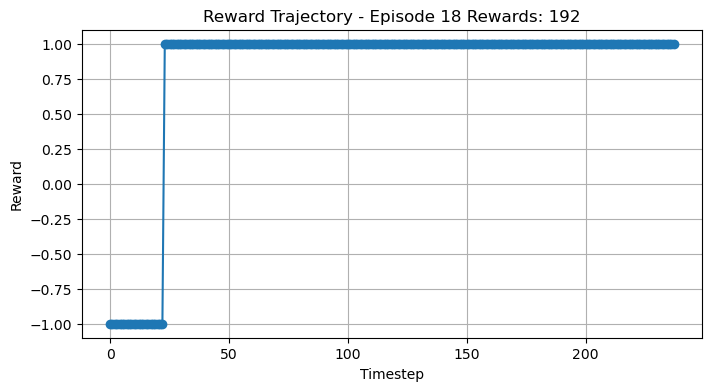

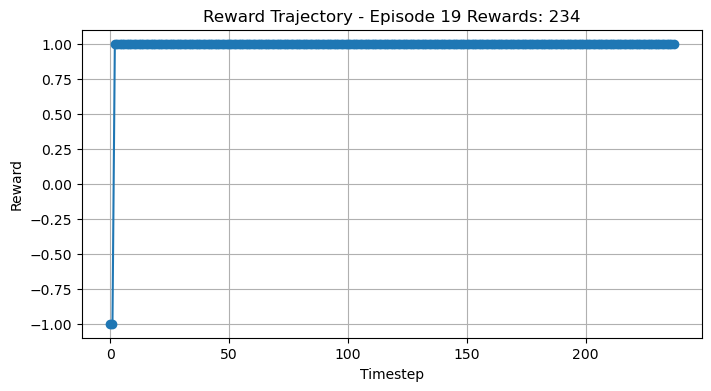

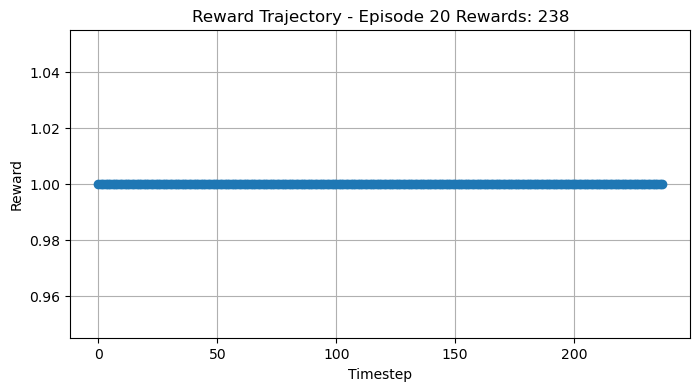

In [16]:
import gymnasium as gym
import pulsrEnv 
from stable_baselines3 import DQN
import matplotlib.pyplot as plt
import numpy as np


env = gym.make("pulsr-virtualenv-v0", workspace_csv="workspace_coordinates/workspace_1.csv", trajectory_csv="track_trajectory_coordinates/track_trajectory_1.csv")

# Load model
model = DQN.load("models/dqn_pulsr_virtualenv_100000")
n_episodes = 20
timesteps_per_episode = 239

obs, info = env.reset()
sum_ep_r = []

for ep in range(n_episodes):
    episode_rewards = []
    for t in range(timesteps_per_episode):
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        episode_rewards.append(reward)

        if terminated or truncated:
            break

    sum_ep_r.append(sum(episode_rewards))
    # --- Plot after each episode ---
    plt.figure(figsize=(8,4))
    plt.plot(range(len(episode_rewards)), episode_rewards, marker="o")
    plt.title(f"Reward Trajectory - Episode {ep+1} Rewards: {sum(episode_rewards)}")
    plt.xlabel("Timestep")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.show()

    # Reset env for next episode
    obs, info = env.reset()

In [17]:
# mean reward for 10000 timesteps_model
np.mean(sum_ep_r)

np.float64(230.5)